In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from google.colab import drive

# Modelos de Aprendizado de Máquina (Aula Prática)

Nesta aula vamos treinar **quatro modelos de Machine Learning**.
A ideia é sempre seguir o **mesmo padrão**:

1. Carregar o dataset  
2. Criar o modelo  
3. Treinar o modelo (`fit`)  
4. Fazer previsões (`predict`)  
5. Visualizar os resultados  

Modelos da aula:

- Regressão Linear
- Regressão Logística

## 🚀 Início do Notebook: Preparando o Terreno para Machine Learning

Este notebook tem como objetivo principal demonstrar o processo de treinamento e avaliação de **Modelos de Machine Learning**, com foco inicial na Regressão Logística. Seguiremos um padrão estruturado para cada modelo, garantindo clareza e reprodutibilidade.

### 📦 1. Importação de Bibliotecas Essenciais

Antes de mergulhar nos modelos, precisamos importar as ferramentas necessárias. As células a seguir carregam bibliotecas fundamentais para manipulação de dados, divisão de conjuntos (treino/teste) e avaliação de performance.

## Carregamento e Pré-processamento dos Dados

Nosso primeiro passo prático é carregar o dataset que utilizaremos para treinar e testar o modelo. A qualidade do dado é crucial para o desempenho do modelo, por isso, realizamos algumas etapas de pré-processamento para garantir que ele esteja pronto para uso.

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/dfProcessado.csv')

# Drop 'Unnamed: 0' column if it exists, as it's often an artifact from saving DataFrames
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Remove duplicates to ensure data consistency
df = df.drop_duplicates()

print("DataFrame 'df' loaded successfully, 'Unnamed: 0' column dropped (if present), and duplicates removed.")

Mounted at /content/drive
DataFrame 'df' loaded successfully, 'Unnamed: 0' column dropped (if present), and duplicates removed.


### Tratamento de Valores Nulos

In [ ]:
# Verificar valores nulos
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


Foi realizada a verificação da existência de valores nulos na base de dados. Não foram identificados valores ausentes, não sendo necessário aplicar técnicas de imputação ou remoção de registros.

### Conversão de Tipos de Dados

In [ ]:
# Verificar os tipos de dados do DataFrame
print(df.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object


Foi realizada a verificação dos tipos das variáveis presentes na base de dados, confirmando que os atributos estavam adequadamente configurados para análise e treinamento dos modelos.

### Criação de Novas Variáveis

Não foi necessária a criação de novas variáveis, sendo utilizadas as características físico-químicas originais disponibilizadas pelo conjunto de dados.

### Remoção de Outliers

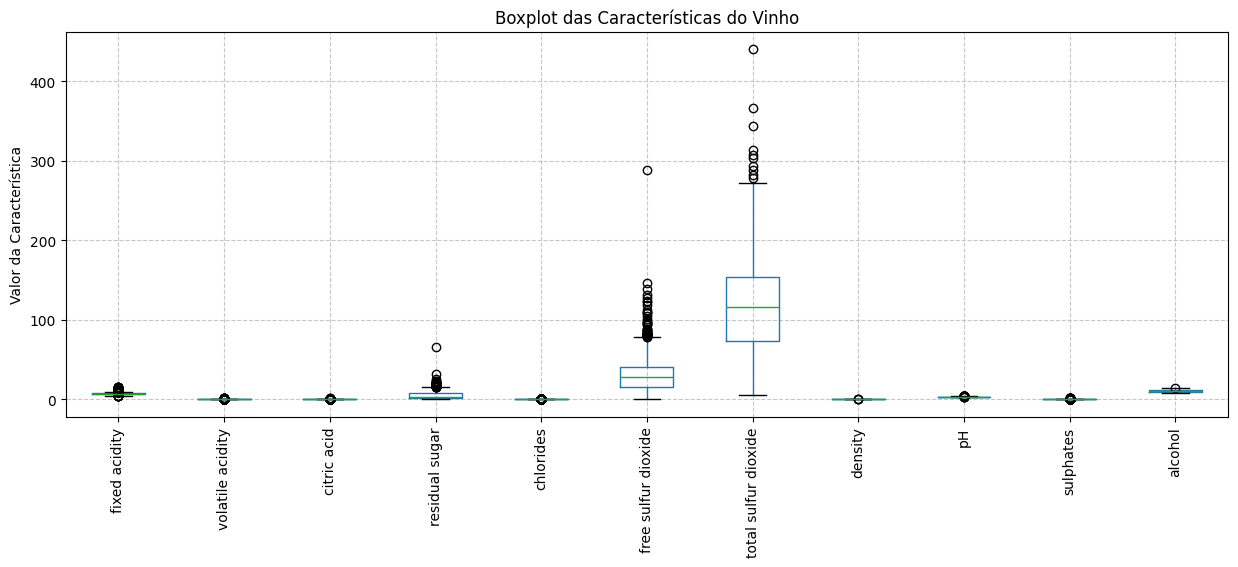

In [ ]:
import matplotlib.pyplot as plt

# Para o boxplot, vamos usar as features numéricas do df, excluindo 'quality' e 'type'.
df_for_boxplot = df.drop(columns=['quality', 'type'], errors='ignore')

df_for_boxplot.boxplot(figsize=(15,5))
plt.xticks(rotation=90)
plt.title('Boxplot das Características do Vinho')
plt.ylabel('Valor da Característica')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Separando Features e Target

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/dfProcessado.csv')
df = df.drop(columns=['Unnamed: 0'])

# Remover duplicados para garantir consistência com o restante do notebook
df = df.drop_duplicates()

# Definir X_unscaled e y de forma consistente
X_unscaled = df.drop(columns=["quality", "type"])
y = df["quality"]

# Re-dividir e padronizar para esta seção para garantir consistência em caso de execução isolada.
# As variáveis X_train, X_test, y_train, y_test serão recriadas aqui.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_unscaled, y, test_size=0.1, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


print("DataFrame 'df' carregado, duplicados removidos e X_unscaled/y e X_train/X_test/y_train/y_test definidos com sucesso para a validação cruzada!")

Mounted at /content/drive
DataFrame 'df' carregado, duplicados removidos e X_unscaled/y e X_train/X_test/y_train/y_test definidos com sucesso para a validação cruzada!


## Criando e Treinando o Modelo de Regressão Logística

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_df = LogisticRegression()
modelo_df.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Realizando Previsões (Regressão Logística)

In [ ]:
pred = modelo_df.predict(X_test)

### Gráfico Interativo das Previsões (Regressão Logística)

In [ ]:
import plotly.express as px
import pandas as pd

vis_df = pd.DataFrame({
    'Amostra': range(len(y_test)),
    'Qualidade Real': y_test.reset_index(drop=True),
    'Qualidade Predita': pred
})

fig = px.scatter(vis_df, x='Amostra', y=['Qualidade Real', 'Qualidade Predita'],
                 title='Regressão Logística: Qualidade Real vs. Predita (Interativo)',
                 labels={'value': 'Qualidade do Vinho', 'variable': 'Tipo de Qualidade'},
                 color_discrete_map={'Qualidade Real': 'blue', 'Qualidade Predita': 'red'})

fig.update_layout(
    xaxis_title="Amostras do Teste",
    yaxis_title="Qualidade do Vinho",
    legend_title="Legenda",
    hovermode="x unified"
)

fig.show()

In [ ]:
# Importando as bibliotecas necessárias para validação cruzada
# KFold: para dividir o dataset em múltiplos subconjuntos (folds)
# cross_val_score: para facilmente realizar a validação cruzada e obter as pontuações
from sklearn.model_selection import KFold, cross_val_score
import numpy as np # Importa numpy para cálculos numéricos, como a média dos scores

print("Bibliotecas KFold, cross_val_score e numpy importadas com sucesso!")

Bibliotecas KFold, cross_val_score e numpy importadas com sucesso!


In [ ]:
# 1. Definindo o número de folds (k)
# Vamos usar 5 folds, o que significa que o conjunto de treino será dividido em 5 partes.
# Em cada iteração, 4 partes serão usadas para treino e 1 para validação.
# shuffle=True: Embaralha os dados antes de dividir para garantir que cada fold seja representativo.
# random_state: Garante que a divisão dos folds seja a mesma em execuções diferentes, para reprodutibilidade.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Objeto KFold criado com {kf.n_splits} splits e shuffle={kf.shuffle}.")

# 2. Aplicando a validação cruzada ao modelo de Regressão Logística
# modelo_df: Nosso modelo de Regressão Logística já inicializado.
# X_train, y_train: Dados de treinamento nos quais o modelo será avaliado.
# cv=kf: Especifica o objeto KFold que acabamos de criar para a estratégia de validação cruzada.
# scoring='accuracy': A métrica de avaliação que queremos usar, neste caso, acurácia.
print("Iniciando a validação cruzada com o modelo de Regressão Logística...")
scores = cross_val_score(modelo_df, X_train, y_train, cv=kf, scoring='accuracy')

# 3. Exibindo os resultados de cada fold
print("\nScores de acurácia para cada fold:")
for i, score in enumerate(scores):
    print(f"  Fold {i+1}: {score:.4f}")

# 4. Calculando a média e o desvio padrão dos scores
# A média nos dá uma estimativa mais robusta da performance do modelo.
# O desvio padrão nos indica o quão consistente foi o desempenho do modelo entre os diferentes folds.
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)

print(f"\n----- Resultados da Validação Cruzada -----")
print(f"Acurácia Média (cross-validation): {mean_accuracy:.4f}")
print(f"Desvio Padrão da Acurácia: {std_accuracy:.4f}")
print("-----------------------------------------")

print("\nIsso significa que, em média, nosso modelo alcançou uma acurácia de "
      f"{mean_accuracy:.2%} com uma variação de {std_accuracy:.2%} entre as diferentes divisões de treino e validação.")

Objeto KFold criado com 5 splits e shuffle=True.
Iniciando a validação cruzada com o modelo de Regressão Logística...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




Scores de acurácia para cada fold:
  Fold 1: 0.5501
  Fold 2: 0.5251
  Fold 3: 0.5574
  Fold 4: 0.5569
  Fold 5: 0.5601

----- Resultados da Validação Cruzada -----
Acurácia Média (cross-validation): 0.5499
Desvio Padrão da Acurácia: 0.0129
-----------------------------------------

Isso significa que, em média, nosso modelo alcançou uma acurácia de 54.99% com uma variação de 1.29% entre as diferentes divisões de treino e validação.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [ ]:
# Importando a biblioteca necessária para o modelo KNN
from sklearn.neighbors import KNeighborsClassifier

# 1. Criação do modelo KNN
# Definimos o número de vizinhos (n_neighbors) como 5. Você pode experimentar outros valores.
modelo_knn = KNeighborsClassifier(n_neighbors=5)
print(f"Modelo KNeighborsClassifier criado com {modelo_knn.n_neighbors} vizinhos.")

# 2. Treinamento do modelo (usando os dados de treino do dataset de vinho)
modelo_knn.fit(X_train, y_train)
print("Modelo KNN treinado com sucesso!")

Modelo KNeighborsClassifier criado com 5 vizinhos.
Modelo KNN treinado com sucesso!


## Criando e Treinando o Modelo KNN

In [ ]:
# Realizando previsões no conjunto de teste
pred_knn = modelo_knn.predict(X_test)
print("Previsões com KNN realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com KNN:\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo KNN:", round(pred_knn[i]))
    print("-----")

Previsões com KNN realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com KNN:

Qualidade real do vinho: 6
Qualidade prevista pelo modelo KNN: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo KNN: 7
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo KNN: 6
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo KNN: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo KNN: 5
-----


### Avaliação do Modelo KNN: Acurácia

In [ ]:
# Importando a métrica de acurácia (já importada anteriormente, mas repetindo para clareza)
from sklearn.metrics import accuracy_score

# Calculando a acurácia do modelo KNN
accuracy_knn = accuracy_score(y_test, pred_knn)

print(f"Acurácia do modelo KNN na previsão da qualidade do vinho: {accuracy_knn:.4f}")

print("\nRelatório de Classificação para KNN:")
print(classification_report(y_test, pred_knn))

print("\nMatriz de Confusão para KNN:")
print(confusion_matrix(y_test, pred_knn))

Acurácia do modelo KNN na previsão da qualidade do vinho: 0.5019

Relatório de Classificação para KNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.20      0.11      0.14        19
           5       0.53      0.61      0.57       181
           6       0.50      0.53      0.51       226
           7       0.49      0.40      0.44        90
           8       0.00      0.00      0.00        14

    accuracy                           0.50       532
   macro avg       0.29      0.27      0.28       532
weighted avg       0.48      0.50      0.49       532


Matriz de Confusão para KNN:
[[  0   0   1   1   0   0]
 [  0   2   7   8   1   1]
 [  0   6 110  61   4   0]
 [  0   2  80 119  25   0]
 [  0   0   8  45  36   1]
 [  0   0   1   5   8   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### Visualização das Previsões vs. Valores Reais (KNN)

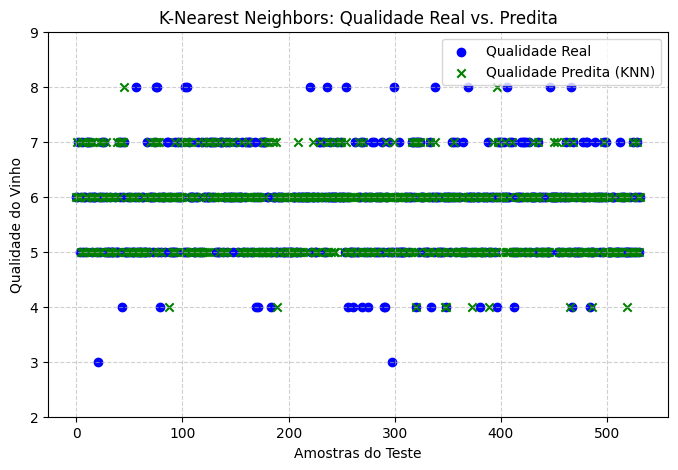

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_knn)), pred_knn,
            marker="x", color="green", label="Qualidade Predita (KNN)") # Gráfico de pontos para valores preditos pelo KNN

# Ajusta os limites do eixo y para mostrar a faixa de qualidade do vinho
plt.ylim(min(y_test.min(), pred_knn.min()) - 1, max(y_test.max(), pred_knn.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("K-Nearest Neighbors: Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Treinando o Modelo de Árvore de Decisão (Classificação)

In [ ]:
# 1. Criação do modelo de Árvore de Decisão para Classificação
# random_state garante reprodutibilidade
clf_tree = DecisionTreeClassifier(random_state=42)
print("Modelo DecisionTreeClassifier para classificação criado.")

# 2. Treinamento do modelo
clf_tree.fit(X_train, y_train)
print("Modelo de Árvore de Decisão treinado com sucesso!")

Modelo DecisionTreeClassifier para classificação criado.
Modelo de Árvore de Decisão treinado com sucesso!


### Realizando Previsões (Árvore de Decisão - Classificação)

In [ ]:
# Realizando previsões no conjunto de teste
pred_tree = clf_tree.predict(X_test)
print("Previsões com Árvore de Decisão realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com Árvore de Decisão:\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo Árvore de Decisão:", pred_tree[i])
    print("-----")

Previsões com Árvore de Decisão realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com Árvore de Decisão:

Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----


### Avaliação: Acurácia (Árvore de Decisão - Classificação)

In [ ]:
# Calculando a acurácia do modelo de Árvore de Decisão
accuracy_tree = accuracy_score(y_test, pred_tree)

print(f"Acurácia do modelo de Árvore de Decisão: {accuracy_tree:.4f}")

Acurácia do modelo de Árvore de Decisão: 0.4812


### Relatório de Classificação (Árvore de Decisão - Classificação)

In [ ]:
print("Relatório de Classificação para Árvore de Decisão:")
print(classification_report(y_test, pred_tree))

Relatório de Classificação para Árvore de Decisão:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.22      0.26      0.24        19
           5       0.56      0.61      0.58       181
           6       0.52      0.47      0.50       226
           7       0.38      0.34      0.36        90
           8       0.10      0.14      0.12        14

    accuracy                           0.48       532
   macro avg       0.30      0.31      0.30       532
weighted avg       0.48      0.48      0.48       532



### Matriz de Confusão (Árvore de Decisão - Classificação)

In [ ]:
print("Matriz de Confusão para Árvore de Decisão:")
print(confusion_matrix(y_test, pred_tree))

Matriz de Confusão para Árvore de Decisão:
[[  0   0   2   0   0   0]
 [  0   5   7   5   1   1]
 [  0   8 111  53   7   2]
 [  1   9  68 107  37   4]
 [  0   1  12  35  31  11]
 [  1   0   0   5   6   2]]


### Visualização das Previsões vs. Valores Reais (Árvore de Decisão - Classificação)

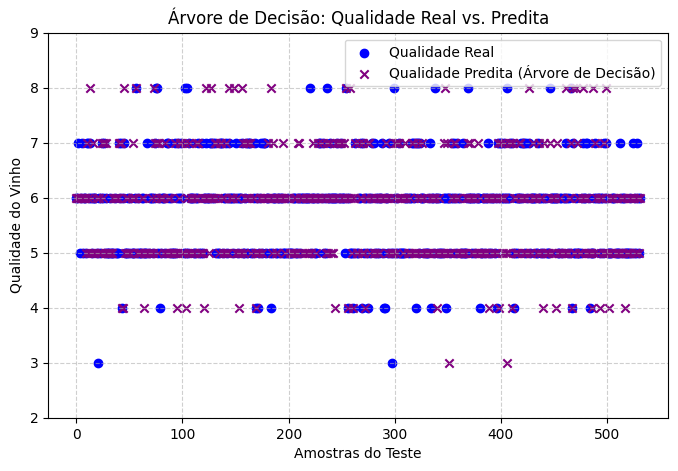

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_tree)), pred_tree,
            marker="x", color="purple", label="Qualidade Predita (Árvore de Decisão)") # Gráfico de pontos para valores preditos

# Ajusta os limites do eixo y
plt.ylim(min(y_test.min(), pred_tree.min()) - 1, max(y_test.max(), pred_tree.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("Árvore de Decisão: Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Treinando o Modelo Random Forest (Classificação)

In [ ]:
# 1. Criação do modelo Random Forest para Classificação
# n_estimators: número de árvores na floresta
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
print(f"Modelo RandomForestClassifier para classificação criado com {clf_rf.n_estimators} árvores.")

# 2. Treinamento do modelo
clf_rf.fit(X_train, y_train)
print("Modelo Random Forest treinado com sucesso!")

Modelo RandomForestClassifier para classificação criado com 100 árvores.
Modelo Random Forest treinado com sucesso!


### Realizando Previsões (Random Forest - Classificação)

In [ ]:
# Realizando previsões no conjunto de teste
pred_rf = clf_rf.predict(X_test)
print("Previsões com Random Forest realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com Random Forest:\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo Random Forest:", pred_rf[i])
    print("-----")

Previsões com Random Forest realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com Random Forest:

Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----


### Avaliação: Acurácia (Random Forest - Classificação)

In [ ]:
# Calculando a acurácia do modelo Random Forest
accuracy_rf = accuracy_score(y_test, pred_rf)

print(f"Acurácia do modelo Random Forest: {accuracy_rf:.4f}")

Acurácia do modelo Random Forest: 0.5808


### Relatório de Classificação (Random Forest - Classificação)

In [ ]:
print("Relatório de Classificação para Random Forest:")
print(classification_report(y_test, pred_rf))

Relatório de Classificação para Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.50      0.11      0.17        19
           5       0.64      0.67      0.65       181
           6       0.55      0.69      0.61       226
           7       0.56      0.32      0.41        90
           8       0.00      0.00      0.00        14

    accuracy                           0.58       532
   macro avg       0.37      0.30      0.31       532
weighted avg       0.56      0.58      0.56       532



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### Matriz de Confusão (Random Forest - Classificação)

In [ ]:
print("Matriz de Confusão para Random Forest:")
print(confusion_matrix(y_test, pred_rf))

Matriz de Confusão para Random Forest:
[[  0   0   1   1   0   0]
 [  0   2  10   7   0   0]
 [  0   2 122  56   1   0]
 [  0   0  56 156  14   0]
 [  0   0   3  57  29   1]
 [  0   0   0   6   8   0]]


### Visualização das Previsões vs. Valores Reais (Random Forest - Classificação)

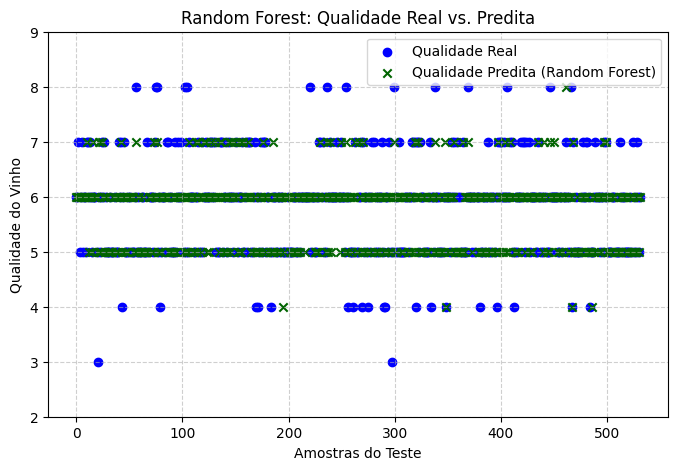

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_rf)), pred_rf,
            marker="x", color="darkgreen", label="Qualidade Predita (Random Forest)") # Gráfico de pontos para valores preditos

# Ajusta os limites do eixo y
plt.ylim(min(y_test.min(), pred_rf.min()) - 1, max(y_test.max(), pred_rf.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("Random Forest: Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Treinando o Modelo de Árvore de Decisão (Regressão)

In [ ]:
# 1. Criação do modelo de Árvore de Decisão para Regressão
# random_state garante reprodutibilidade
reg_tree = DecisionTreeRegressor(random_state=42)
print("Modelo DecisionTreeRegressor para regressão criado.")

# 2. Treinamento do modelo
reg_tree.fit(X_train, y_train)
print("Modelo de Árvore de Decisão (Regressão) treinado com sucesso!")

Modelo DecisionTreeRegressor para regressão criado.
Modelo de Árvore de Decisão (Regressão) treinado com sucesso!


### Realizando Previsões (Árvore de Decisão - Regressão)

In [ ]:
# Realizando previsões no conjunto de teste
pred_tree_r = reg_tree.predict(X_test)
print("Previsões com Árvore de Decisão (Regressão) realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com Árvore de Decisão (Regressão):\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo Árvore de Decisão:", round(pred_tree_r[i]))
    print("-----")

Previsões com Árvore de Decisão (Regressão) realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com Árvore de Decisão (Regressão):

Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 5
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Árvore de Decisão: 6
-----


### Avaliação: Erro Quadrático Médio (Árvore de Decisão - Regressão)

In [ ]:
# Calculando o Erro Quadrático Médio (MSE) do modelo de Árvore de Decisão
mse_tree_r = mean_squared_error(y_test, pred_tree_r)
rmse_tree_r = np.sqrt(mse_tree_r)
r2_tree_r = r2_score(y_test, pred_tree_r)

print(f"MSE do modelo de Árvore de Decisão (Regressão): {mse_tree_r:.4f}")
print(f"RMSE do modelo de Árvore de Decisão (Regressão): {rmse_tree_r:.4f}")
print(f"R² Score do modelo de Árvore de Decisão (Regressão): {r2_tree_r:.4f}")

MSE do modelo de Árvore de Decisão (Regressão): 0.9023
RMSE do modelo de Árvore de Decisão (Regressão): 0.9499
R² Score do modelo de Árvore de Decisão (Regressão): -0.2016


### Visualização das Previsões vs. Valores Reais (Árvore de Decisão - Regressão)

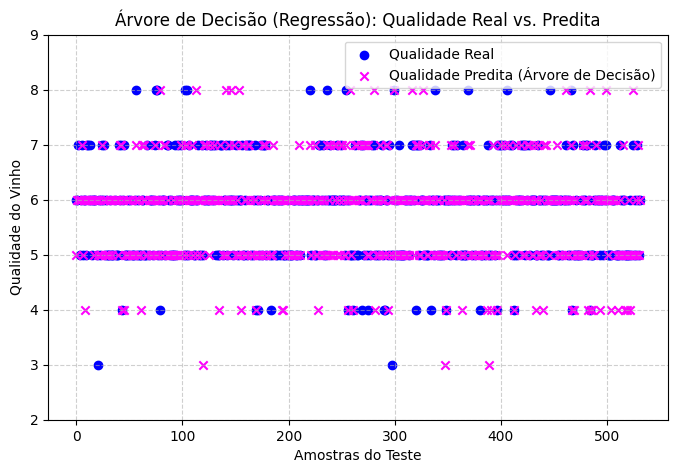

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_tree_r)), pred_tree_r,
            marker="x", color="magenta", label="Qualidade Predita (Árvore de Decisão)") # Gráfico de pontos para valores preditos

# Ajusta os limites do eixo y
plt.ylim(min(y_test.min(), pred_tree_r.min()) - 1, max(y_test.max(), pred_tree_r.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("Árvore de Decisão (Regressão): Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Treinando o Modelo Random Forest (Regressão)

In [ ]:
# 1. Criação do modelo Random Forest para Regressão
# n_estimators: número de árvores na floresta
reg_rf = RandomForestRegressor(n_estimators=100, random_state=42)
print(f"Modelo RandomForestRegressor para regressão criado com {reg_rf.n_estimators} árvores.")

# 2. Treinamento do modelo
reg_rf.fit(X_train, y_train)
print("Modelo Random Forest (Regressão) treinado com sucesso!")

Modelo RandomForestRegressor para regressão criado com 100 árvores.
Modelo Random Forest (Regressão) treinado com sucesso!


### Realizando Previsões (Random Forest - Regressão)

In [ ]:
# Realizando previsões no conjunto de teste
pred_rf_r = reg_rf.predict(X_test)
print("Previsões com Random Forest (Regressão) realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com Random Forest (Regressão):\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo Random Forest:", round(pred_rf_r[i]))
    print("-----")

Previsões com Random Forest (Regressão) realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com Random Forest (Regressão):

Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo Random Forest: 7
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo Random Forest: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Random Forest: 6
-----


### Avaliação: Erro Quadrático Médio (Random Forest - Regressão)

In [ ]:
# Calculando o Erro Quadrático Médio (MSE) do modelo Random Forest
mse_rf_r = mean_squared_error(y_test, pred_rf_r)
rmse_rf_r = np.sqrt(mse_rf_r)
r2_rf_r = r2_score(y_test, pred_rf_r)

print(f"MSE do modelo Random Forest (Regressão): {mse_rf_r:.4f}")
print(f"RMSE do modelo Random Forest (Regressão): {rmse_rf_r:.4f}")
print(f"R² Score do modelo Random Forest (Regressão): {r2_rf_r:.4f}")

MSE do modelo Random Forest (Regressão): 0.4243
RMSE do modelo Random Forest (Regressão): 0.6514
R² Score do modelo Random Forest (Regressão): 0.4350


### Visualização das Previsões vs. Valores Reais (Random Forest - Regressão)

## Treinando o Modelo de Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Criação do modelo de Regressão Linear
lin_reg = LinearRegression()
print("Modelo LinearRegression para regressão criado.")

# 2. Treinamento do modelo
lin_reg.fit(X_train, y_train)
print("Modelo de Regressão Linear treinado com sucesso!")

Modelo LinearRegression para regressão criado.
Modelo de Regressão Linear treinado com sucesso!


### Realizando Previsões (Regressão Linear)

In [ ]:
pred_lin_reg = lin_reg.predict(X_test)
print("Previsões com Regressão Linear realizadas com sucesso!")

print("\nExemplos de previsão da qualidade do vinho com Regressão Linear:\n")
for i in range(5):
    print("Qualidade real do vinho:", y_test.iloc[i])
    print("Qualidade prevista pelo modelo Regressão Linear:", round(pred_lin_reg[i]))
    print("-----")

Previsões com Regressão Linear realizadas com sucesso!

Exemplos de previsão da qualidade do vinho com Regressão Linear:

Qualidade real do vinho: 6
Qualidade prevista pelo modelo Regressão Linear: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Regressão Linear: 6
-----
Qualidade real do vinho: 7
Qualidade prevista pelo modelo Regressão Linear: 7
-----
Qualidade real do vinho: 5
Qualidade prevista pelo modelo Regressão Linear: 6
-----
Qualidade real do vinho: 6
Qualidade prevista pelo modelo Regressão Linear: 6
-----


### Avaliação: Erro Quadrático Médio (Regressão Linear)

In [ ]:
mse_lin_reg = mean_squared_error(y_test, pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test, pred_lin_reg)

print(f"MSE do modelo Regressão Linear: {mse_lin_reg:.4f}")
print(f"RMSE do modelo Regressão Linear: {rmse_lin_reg:.4f}")
print(f"R² Score do modelo Regressão Linear: {r2_lin_reg:.4f}")

MSE do modelo Regressão Linear: 0.5247
RMSE do modelo Regressão Linear: 0.7243
R² Score do modelo Regressão Linear: 0.3013


### Visualização das Previsões vs. Valores Reais (Regressão Linear)

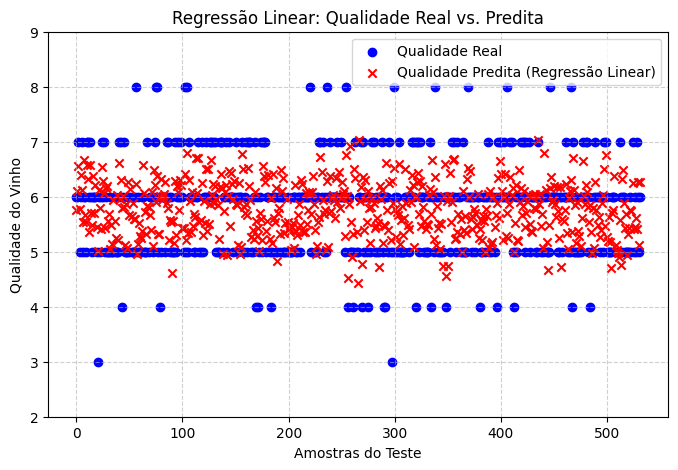

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_lin_reg)), pred_lin_reg,
            marker="x", color="red", label="Qualidade Predita (Regressão Linear)") # Gráfico de pontos para valores preditos

# Ajusta os limites do eixo y
plt.ylim(min(y_test.min(), pred_lin_reg.min()) - 1, max(y_test.max(), pred_lin_reg.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("Regressão Linear: Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

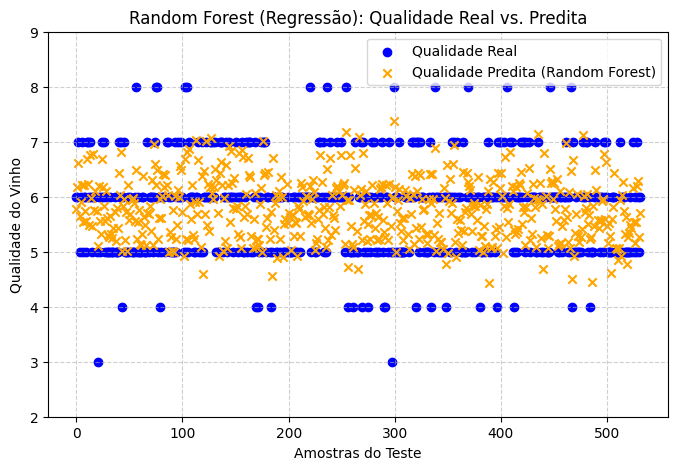

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test.reset_index(drop=True),
            marker="o", color="blue", label="Qualidade Real") # Gráfico de pontos para valores reais

plt.scatter(range(len(pred_rf_r)), pred_rf_r,
            marker="x", color="orange", label="Qualidade Predita (Random Forest)") # Gráfico de pontos para valores preditos

# Ajusta os limites do eixo y
plt.ylim(min(y_test.min(), pred_rf_r.min()) - 1, max(y_test.max(), pred_rf_r.max()) + 1)

plt.xlabel("Amostras do Teste")
plt.ylabel("Qualidade do Vinho")
plt.title("Random Forest (Regressão): Qualidade Real vs. Predita")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5320 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5320 non-null   float64
 1   volatile acidity      5320 non-null   float64
 2   citric acid           5320 non-null   float64
 3   residual sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free sulfur dioxide   5320 non-null   float64
 6   total sulfur dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  type                  5320 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 581.9+ KB


### Explicação das colunas

• fixed acidity → acidez fixa do vinho (não evapora facilmente, influencia no sabor)

• volatile acidity → acidez volátil (quanto maior, maior chance de gosto azedo/avinagrado)

• citric acid → ácido cítrico (ajuda no frescor e sabor do vinho)

• residual sugar → quantidade de açúcar residual após a fermentação

• chlorides → quantidade de sal no vinho

• free sulfur dioxide → dióxido de enxofre livre (atua como conservante)

• total sulfur dioxide → quantidade total de dióxido de enxofre (livre + combinado)

• density → densidade do vinho (relacionada ao teor de álcool e açúcar)

• pH → nível de acidez do vinho (quanto menor, mais ácido)

• sulphates → sulfatos (ajudam na conservação e estabilidade do vinho)

• alcohol → teor alcoólico do vinho (% de álcool)

• quality → nota de qualidade do vinho (geralmente de 0 a 10)

• type → tipo do vinho (ex: tinto ou branco)

In [ ]:
display(df.median(numeric_only=True))

,0
fixed acidity,7.00000
volatile acidity,0.30000
citric acid,0.31000
residual sugar,2.70000
chlorides,0.04700
free sulfur dioxide,28.00000
total sulfur dioxide,116.00000
density,0.99465
pH,3.21000
sulphates,0.51000


In [ ]:
display(df.mode().head(1))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,6.8,0.28,0.3,1.6,0.036,6.0,111.0,0.992,3.16,0.5,9.5,6.0,white


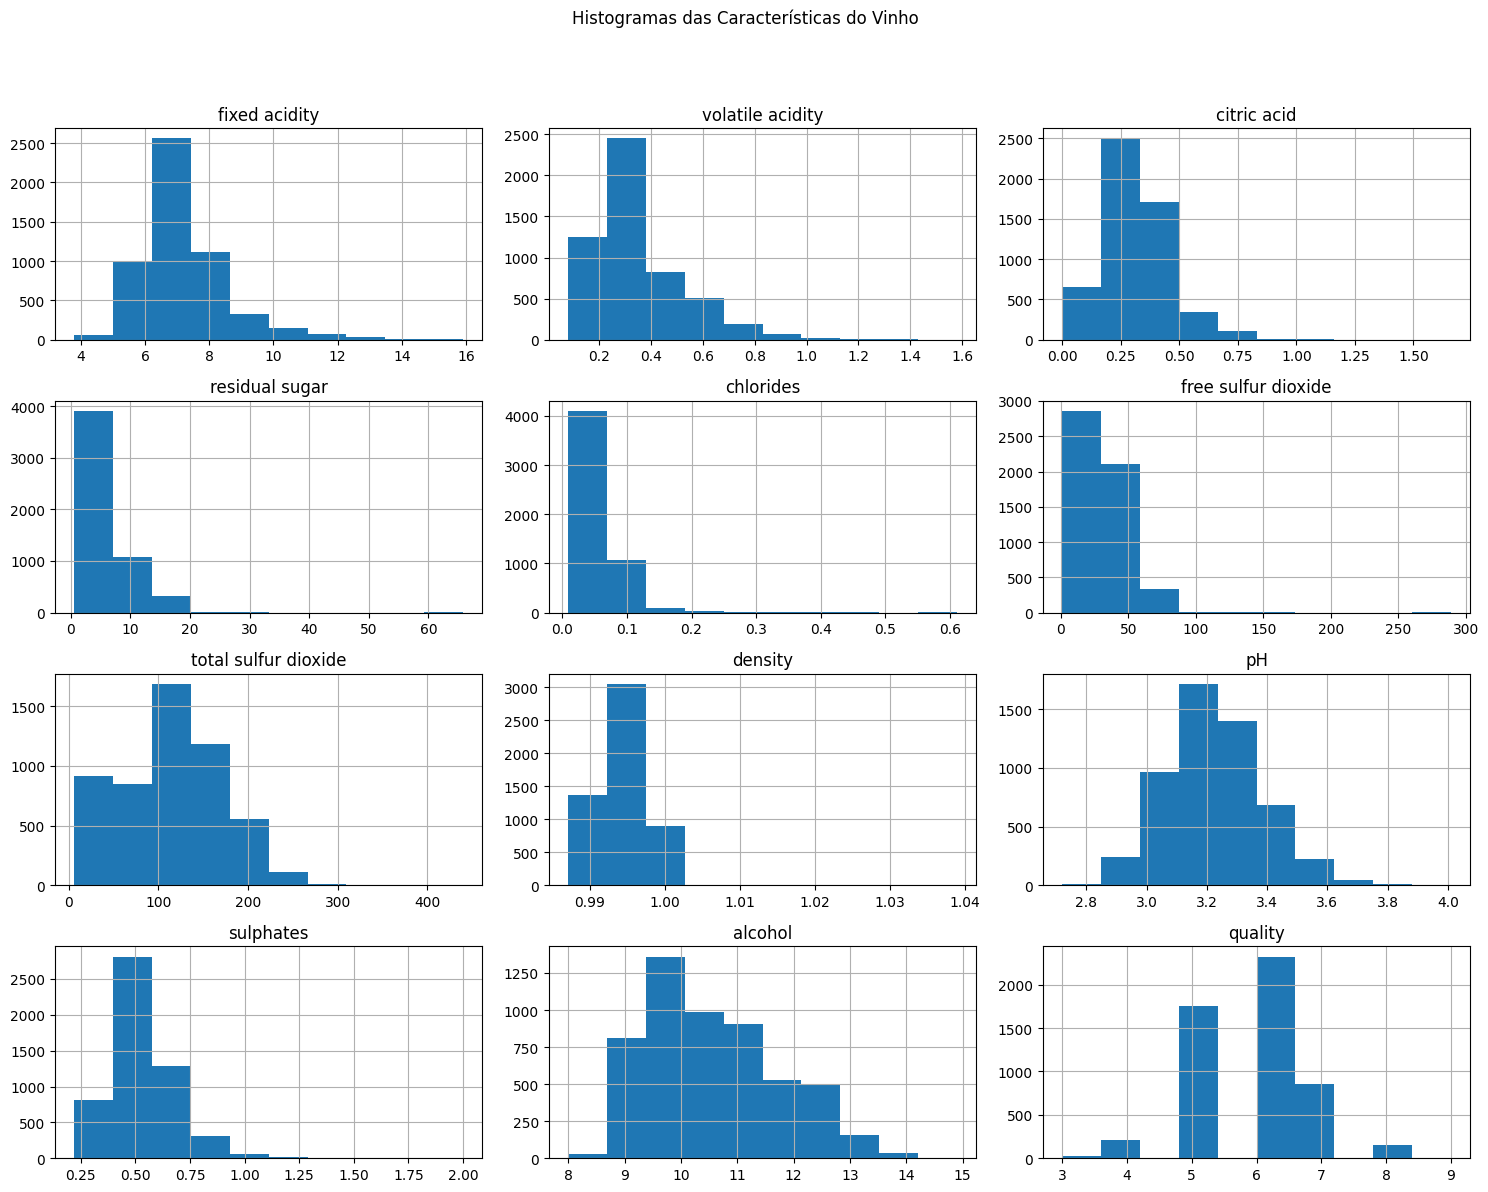

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,12))
plt.suptitle('Histogramas das Características do Vinho', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para evitar sobreposição
plt.show()

## Conclusão

Neste notebook, foi explorado e implementado diversos modelos de Machine Learning para a previsão da qualidade do vinho, seguindo um padrão consistente de carregamento de dados, criação de modelo, treinamento, previsão e visualização de resultados.

### Modelos Implementados e Seus Desempenhos:

1.  **Regressão Logística (Classificação):**
    *   Este modelo foi o ponto de partida, demonstrando como classificar a qualidade do vinho. Sua acurácia média foi avaliada através de validação cruzada, oferecendo uma estimativa robusta de seu desempenho.

2.  **K-Nearest Neighbors (KNN - Classificação):**
    *   Foi Implementado o KNN, um modelo baseado na proximidade dos dados. As métricas de acurácia, relatório de classificação e matriz de confusão forneceram insights sobre sua capacidade de agrupar vinhos de qualidade semelhante.

3.  **Árvore de Decisão (Classificação):**
    *   O modelo de Árvore de Decisão foi treinado para classificar a qualidade do vinho, com uma análise detalhada de acurácia, relatório de classificação e matriz de confusão, mostrando como as decisões são tomadas com base nas características.

4.  **Random Forest (Classificação):**
    *   Como uma extensão da Árvore de Decisão, o Random Forest utilizou múltiplos classificadores para melhorar a robustez e a acurácia. Suas métricas de avaliação indicaram um desempenho geralmente superior em comparação com uma única árvore.

5.  **Árvore de Decisão (Regressão):**
    *   Foi Adaptado a Árvore de Decisão para uma tarefa de regressão, visando prever a qualidade do vinho como um valor contínuo. O Erro Quadrático Médio (MSE) e o R² score foram utilizados para avaliar a precisão das previsões.

6.  **Random Forest (Regressão):**
    *   Similarmente, o Random Forest foi aplicado à regressão, utilizando o poder de múltiplos regressores para fornecer previsões mais estáveis e precisas, conforme demonstrado pelo MSE e R² score.

7.  **Regressão Linear (Regressão):**
    *   Por fim, foi adicionado o modelo de Regressão Linear, um algoritmo clássico para previsão de valores contínuos. Avaliamos seu desempenho com MSE, RMSE e R² score, oferecendo uma linha de base para comparação com os modelos mais complexos.

